# Methods Tutorial: Stereo-to-Mono Audio Conversion

## Introduction

This tutorial teaches how to convert **stereo** audio (2 channels) into **mono** audio (1 channel) and resample it to **16 kHz** — a common preprocessing step before speech recognition.

Everything you need is contained in this notebook. You do not need any external project files.

### What You'll Learn

By the end of this tutorial, you will understand:

- What a **WAV file** is and how digital audio is stored inside it
- The difference between **mono** and **stereo** formats, and why conversion is needed
- Key **acoustic and audio terminology** (sample rate, channels, amplitude, waveform, resampling)
- Why stereo recordings must be converted to mono for many ASR models
- How to load a WAV file with `soundfile`
- Why audio is converted from NumPy to a PyTorch tensor before downmixing and resampling
- How stereo is converted to mono by averaging the left and right channels
- How to resample audio to 16 kHz with `torchaudio`
- How to verify the final output is mono at the target sample rate
- How to **visualize** stereo and mono waveforms before and after conversion

## Tutorial Layout

| Part | Section | Topic |
|------|---------|-------|
| **Opening** | Introduction | Goals, scope, and what you will learn |
| **Opening** | Overview | End-to-end pipeline summary |
| **Background** | A | What is a WAV file? |
| **Background** | B | Mono vs. stereo — formats in detail |
| **Background** | C | Audio acoustics & terminology |
| **Setup** | — | Install from `requirements.txt` (before starting) |
| **Setup** | 1 | Import libraries |
| **Setup** | 2 | Define preprocessing functions |
| **Setup** | 3 | Create demo stereo audio |
| **Implementation** | 4 | Step 1 — Load the WAV file |
| **Implementation** | 5 | Step 2 — Convert to PyTorch tensor (and why) |
| **Implementation** | 6 | Step 3 — Stereo → mono via channel averaging |
| **Implementation** | 7 | Step 4 — Resample to 16 kHz |
| **Implementation** | 8 | Step 5 — Validate and return mono output |
| **Implementation** | 9 | Run the full pipeline |
| **Visualization** | 11 | Waveform plot: before and after channel averaging |
| **Summary** | 12 | Flow summary, key point, and save mono output |
| **Conclusion** | 13 | What you learned and next steps |

## Overview

Audio recordings are often captured in **stereo** (left + right channels). Many speech recognition models expect **mono** audio at a fixed sample rate (commonly **16 kHz**).

This notebook implements a complete preprocessing pipeline:

1. Load WAV → NumPy array
2. Convert to PyTorch tensor with shape `[channels, samples]`
3. Average channels → mono
4. Resample → 16 kHz
5. Return a 1D NumPy array ready for downstream use

## A. What Is a WAV File?

**WAV** (Waveform Audio File Format) is one of the most common formats for storing **uncompressed digital audio** on a computer. Files typically use the `.wav` extension.

### How a WAV file is structured

A WAV file has two main parts:

1. **Header** — metadata describing the audio (sample rate, number of channels, bit depth, duration)
2. **Audio data** — the actual recorded sound, stored as a sequence of numeric **samples**

WAV files usually store audio as **PCM** (Pulse Code Modulation): each sample is a number representing the **amplitude** (air pressure level) of the sound wave at one instant in time.

### Why WAV is used in this tutorial

| Property | Why it matters |
|----------|----------------|
| **Uncompressed** | No quality loss from compression — the raw waveform is preserved |
| **Widely supported** | Readable by Python libraries such as `soundfile` without extra codecs |
| **Simple structure** | Easy to load as a NumPy array for processing |
| **Common in research** | Many speech datasets (including medical recordings) are distributed as WAV |

When we call `sf.read("file.wav")`, the library reads the header, decodes the PCM samples, and returns a NumPy array of floating-point values (typically between −1.0 and +1.0) along with the **sample rate** in Hz.

## B. Mono vs. Stereo — Formats in Detail

Audio can be stored with one or more **channels** — independent streams of sound data captured or mixed separately.

### Mono (1 channel)

- **Mono** audio uses a **single channel**: one waveform, one sequence of samples.
- The same signal is intended for all listeners/speakers — there is no left/right separation.
- In code, a mono WAV loaded by `soundfile` has shape **`[samples]`** (a 1D array).

```
Mono:  sample₀  sample₁  sample₂  sample₃  ...
       ─────────────────────────────────────
       one continuous waveform
```

**Typical use:** telephone speech, voice assistants, many ASR models, podcasts.

### Stereo (2 channels)

- **Stereo** audio uses **two channels**: usually **left (L)** and **right (R)**.
- Each channel has its own waveform. Together they can convey spatial information (where a sound appears to come from).
- In code, a stereo WAV loaded by `soundfile` has shape **`[samples, 2]`** — each row is a time point, columns are L and R amplitudes.

```
Stereo:  Time →
         L:  sample₀  sample₁  sample₂  ...
         R:  sample₀  sample₁  sample₂  ...
```

**Typical use:** music recordings, field recordings with two microphones, consumer audio devices.

### Side-by-side comparison

| | Mono | Stereo |
|---|------|--------|
| **Channels** | 1 | 2 (L + R) |
| **NumPy shape** | `[samples]` | `[samples, 2]` |
| **Tensor shape (after conversion)** | `[1, samples]` | `[2, samples]` |
| **Spatial information** | None | Left/right separation |
| **File size (same duration & rate)** | Smaller | ~2× mono |

### Why convert stereo to mono?

Many speech recognition systems — including those used for medical transcription — are trained on **mono** input. Stereo adds a second channel that often carries **redundant speech information** (the same voice in both ears) while doubling processing complexity.

**Downmixing** combines the channels into one. In this tutorial, that means **averaging**:

$$\text{mono}(t) = \frac{\text{left}(t) + \text{right}(t)}{2}$$

Here, **t** is **time** — each value of *t* is one sample instant in the recording (sample index 0, 1, 2, …). The expressions `left(t)` and `right(t)` are the amplitudes in the left and right channels at that moment, and `mono(t)` is the single combined amplitude written to the output.

This preserves the speech content while producing the single-channel format the pipeline expects.

## C. Audio Acoustics & Terminology

This section defines the acoustic and technical terms used throughout the rest of the tutorial.

### From sound in air to numbers in a file

1. **Sound** is a pressure wave travelling through air (or another medium).
2. A **microphone** converts changing air pressure into an **analog electrical signal**.
3. An **analog-to-digital converter (ADC)** measures that signal at regular intervals and stores each measurement as a **sample** — a number in the WAV file.

The complete set of samples over time is called the **waveform**.

### Key terms

| Term | Definition | In this tutorial |
|------|------------|------------------|
| **Sample** | One numeric measurement of the waveform at a single instant | One float32 value in the NumPy array |
| **Sample rate (`sr`)** | How many samples are recorded per second, in **Hz** (samples/s) | e.g. 44100 Hz (CD quality), 16000 Hz (speech standard) |
| **Amplitude** | The strength or loudness of the wave at a given moment; stored as the sample value | Values roughly between −1.0 and +1.0 after loading with `soundfile` |
| **Frequency** | How many oscillation cycles per second a tone contains, in **Hz** | Demo tone uses 440 Hz (musical note A4) |
| **Channel** | An independent audio stream (mono = 1, stereo = 2) | `wav.shape[0]` after converting to `[channels, samples]` |
| **Waveform** | A plot (or array) of amplitude vs. time | The NumPy / tensor array we process |
| **PCM** | Pulse Code Modulation — uncompressed sample-by-sample digital audio | The data format inside a WAV file |
| **Downmix / downmixing** | Combining multiple channels into fewer channels | Stereo → mono by averaging L and R |
| **Resampling** | Changing the sample rate (e.g. 44100 → 16000 Hz) | Done with `torchaudio.transforms.Resample` |
| **Bit depth** | Number of bits per sample in the file (e.g. 16-bit, 24-bit) | `soundfile` converts to float32 for processing |

### Sample rate and speech

Human speech contains most of its energy below ~8 kHz. By the **Nyquist–Shannon sampling theorem**, a sample rate must be at least **twice** the highest frequency you want to capture. That is why **16 kHz** (capturing up to 8 kHz) is a standard rate for speech recognition — it preserves the content needed for transcription while keeping files smaller and processing faster than CD-quality 44.1 kHz.

### How the terms connect in the pipeline

```
Physical sound  →  microphone  →  ADC  →  WAV file (PCM samples)
                                              ↓
                                    load_wav() → NumPy array + sr
                                              ↓
                                    tensor [channels, samples]
                                              ↓
                                    downmix → mono [1, samples]
                                              ↓
                                    resample → mono @ 16 kHz
                                              ↓
                                    1D NumPy array → ready for downstream use
```

When you see **`sr`**, think *how fast the waveform was measured*. When you see **`shape`**, think *how the samples are organised (channels × time)*. When you see **resample**, think *re-measuring the same waveform at a different rate* — not changing mono/stereo layout.

## Dependencies

Install the required libraries from `requirements.txt` in this folder before running the notebook. Run the cell below:

Packages used: `numpy`, `soundfile`, `torch`, `torchaudio`, `matplotlib`.

In [33]:
!pip install -r requirements.txt

## 2. Import Libraries

In [34]:
from pathlib import Path
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import torch
import torchaudio

## 3. Define Preprocessing Functions

These functions implement the full stereo-to-mono pipeline. 

In [35]:
def load_wav(audio_path: str) -> Tuple[np.ndarray, int]:
    """Load a WAV file as a float32 NumPy array.

    Returns:
        wav_np: Mono shape [samples], stereo shape [samples, channels]
        sr: Sample rate in Hz
    """
    wav_np, sr = sf.read(audio_path, dtype="float32")
    return wav_np, sr


def to_channel_first_tensor(wav_np: np.ndarray) -> torch.Tensor:
    """Convert NumPy audio to a PyTorch tensor with shape [channels, samples]."""
    wav = torch.from_numpy(wav_np)
    if wav.ndim == 1:
        wav = wav.unsqueeze(0)  # [samples] -> [1, samples]
    elif wav.ndim == 2:
        wav = wav.T  # [samples, channels] -> [channels, samples]
    return wav


def stereo_to_mono(wav: torch.Tensor) -> torch.Tensor:
    """Convert multi-channel audio to mono by averaging channels.

    Input shape:  [channels, samples]
    Output shape: [1, samples]
    """
    if wav.shape[0] > 1:
        wav = torch.mean(wav, dim=0, keepdim=True)
    return wav


def resample_audio(wav: torch.Tensor, sr: int, target_sr: int = 16000) -> Tuple[torch.Tensor, int]:
    """Resample audio to the target sample rate if needed."""
    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(sr, target_sr)
        wav = resampler(wav)
        sr = target_sr
    return wav, sr


def validate_mono_16k(wav: torch.Tensor, sr: int, target_sr: int = 16000) -> None:
    """Ensure audio is mono at the target sample rate."""
    assert wav.shape[0] == 1 and sr == target_sr, (
        f"Audio must be mono and {target_sr} Hz, got shape={wav.shape}, sr={sr}"
    )


def preprocess_stereo_to_mono(
    audio_path: str,
    target_sr: int = 16000,
) -> Tuple[np.ndarray, int]:
    """Full pipeline: load WAV, convert to mono, resample, return 1D NumPy array.

    Returns:
        mono_wav_np: 1D NumPy array [samples]
        sr: Sample rate (target_sr)
    """
    wav_np, sr = load_wav(audio_path)
    wav = to_channel_first_tensor(wav_np)
    wav = stereo_to_mono(wav)
    wav, sr = resample_audio(wav, sr, target_sr)
    validate_mono_16k(wav, sr, target_sr)
    mono_wav_np = wav.squeeze().cpu().numpy()  # [1, samples] -> [samples]
    return mono_wav_np, sr


def ensure_demo_stereo() -> Path:
    """Create a synthetic stereo WAV for this tutorial if it does not exist yet."""
    demo_dir = Path("demo_audio")
    demo_dir.mkdir(exist_ok=True)
    demo_path = demo_dir / "demo_stereo.wav"

    if not demo_path.exists():
        duration_sec = 1.0
        demo_sr = 44100
        t = np.linspace(0, duration_sec, int(demo_sr * duration_sec), endpoint=False)
        left = np.sin(2 * np.pi * 440 * t).astype(np.float32)
        right = (0.5 * np.sin(2 * np.pi * 440 * t)).astype(np.float32)
        stereo = np.stack([left, right], axis=1)
        sf.write(demo_path, stereo, demo_sr)

    return demo_path


def _time_axis(num_samples: int, sr: int) -> np.ndarray:
    """Return a time axis in seconds for a given number of samples."""
    return np.arange(num_samples) / sr


def plot_stereo_waveform(
    wav_np: np.ndarray,
    sr: int,
    max_seconds: float = 0.05,
    title: str = "Before averaging: Stereo WAV",
) -> plt.Figure:
    """Plot left and right channel waveforms from a stereo NumPy array."""
    if wav_np.ndim != 2:
        raise ValueError("Expected stereo array with shape [samples, channels]")

    num_samples = min(len(wav_np), int(sr * max_seconds))
    time = _time_axis(num_samples, sr)

    fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
    axes[0].plot(time, wav_np[:num_samples, 0], color="steelblue", linewidth=1)
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title("Left channel")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(time, wav_np[:num_samples, 1], color="coral", linewidth=1)
    axes[1].set_ylabel("Amplitude")
    axes[1].set_title("Right channel")
    axes[1].set_xlabel("Time (s)")
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(f"{title}  |  {sr} Hz  |  shape {wav_np.shape}", fontsize=12)
    plt.tight_layout()
    return fig


def plot_mono_waveform(
    mono_np: np.ndarray,
    sr: int,
    max_seconds: float = 0.05,
    title: str = "Mono WAV",
) -> plt.Figure:
    """Plot a mono waveform from a 1D NumPy array."""
    if mono_np.ndim != 1:
        raise ValueError("Expected mono array with shape [samples]")

    num_samples = min(len(mono_np), int(sr * max_seconds))
    time = _time_axis(num_samples, sr)

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(time, mono_np[:num_samples], color="seagreen", linewidth=1)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"{title}  |  {sr} Hz  |  shape {mono_np.shape}")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig


def plot_before_after_averaging(
    stereo_np: np.ndarray,
    stereo_sr: int,
    mono_np: np.ndarray,
    max_seconds: float = 0.05,
) -> plt.Figure:
    """Plot stereo input and mono output after channel averaging (same sample rate)."""
    stereo_samples = min(len(stereo_np), int(stereo_sr * max_seconds))
    mono_samples = min(len(mono_np), int(stereo_sr * max_seconds))

    stereo_time = _time_axis(stereo_samples, stereo_sr)
    mono_time = _time_axis(mono_samples, stereo_sr)

    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(stereo_time, stereo_np[:stereo_samples, 0], color="steelblue", linewidth=1)
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title(f"Before averaging — Left channel  ({stereo_sr} Hz)")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(stereo_time, stereo_np[:stereo_samples, 1], color="coral", linewidth=1)
    axes[1].set_ylabel("Amplitude")
    axes[1].set_title(f"Before averaging — Right channel  ({stereo_sr} Hz)")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(mono_time, mono_np[:mono_samples], color="seagreen", linewidth=1)
    axes[2].set_ylabel("Amplitude")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title(f"After averaging — Mono  ({stereo_sr} Hz)")
    axes[2].grid(True, alpha=0.3)

    fig.suptitle("Stereo-to-Mono: Before vs. after channel averaging", fontsize=13)
    plt.tight_layout()
    return fig

## 4. Create Demo Stereo Audio

We generate a short synthetic stereo WAV file so you can run every step without needing an external recording.

**Note:** Run Sections 1–3 (Install, Import, Functions) once before running any step cell. Each step cell (5–10) reloads the demo file on its own.

In [36]:
demo_path = ensure_demo_stereo()
wav_np, sr = load_wav(str(demo_path))

print(f"Demo file ready: {demo_path}")
print(f"Shape: {wav_np.shape}  (samples, channels)" if wav_np.ndim == 2 else f"Shape: {wav_np.shape}  (samples,)")
print(f"Sample rate: {sr} Hz")

Demo file ready: demo_audio\demo_stereo.wav
Shape: (44100, 2)  (samples, channels)
Sample rate: 44100 Hz


## 5. Step 1 — Load the WAV File

A WAV file is read with **soundfile** as a float32 NumPy array:

- **Mono file** → shape `[samples]`
- **Stereo file** → shape `[samples, 2]` (left and right per row)

In [37]:
demo_path = ensure_demo_stereo()
wav_np, sr = load_wav(str(demo_path))

print(f"Loaded: {demo_path}")
print(f"NumPy shape: {wav_np.shape}")
print(f"Sample rate: {sr} Hz")

Loaded: demo_audio\demo_stereo.wav
NumPy shape: (44100, 2)
Sample rate: 44100 Hz


## 6. Step 2 — Convert to PyTorch Tensor

### Why convert to PyTorch?

The WAV file is loaded as a **NumPy** array because `soundfile` reads audio into NumPy. Before stereo-to-mono and resampling, we convert it to a **PyTorch tensor** because the next steps use PyTorch and torchaudio:

1. **Channel averaging (stereo → mono)** — `torch.mean(wav, dim=0)` averages left and right along the channel dimension.
2. **Resampling to 16 kHz** — `torchaudio.transforms.Resample` expects a tensor shaped as `[channels, samples]`.

The tensor is used only for preprocessing. The final output is converted back to a 1D NumPy array (Step 5).

In [38]:
demo_path = ensure_demo_stereo()
wav_np, sr = load_wav(str(demo_path))
wav = to_channel_first_tensor(wav_np)

print(f"Tensor shape: {tuple(wav.shape)}  (channels, samples)")
print(f"Number of channels: {wav.shape[0]}")

Tensor shape: (2, 44100)  (channels, samples)
Number of channels: 2


## 7. Step 3 — Stereo → Mono (Channel Averaging)

If there is more than one channel, left and right are **averaged** into one:

| Before | After |
|--------|-------|
| `[2, N]` (stereo) | `[1, N]` (mono) |

Formula: `mono_sample = (left + right) / 2`

In [39]:
demo_path = ensure_demo_stereo()
wav_np, sr = load_wav(str(demo_path))
wav = to_channel_first_tensor(wav_np)

channels_before = wav.shape[0]
wav = stereo_to_mono(wav)

print(f"Channels before: {channels_before}")
print(f"Channels after:  {wav.shape[0]}")
print(f"Tensor shape:    {tuple(wav.shape)}")

Channels before: 2
Channels after:  1
Tensor shape:    (1, 44100)


## 8. Step 4 — Resample to 16 kHz

If the sample rate is not 16 kHz, `torchaudio` resamples the audio. This step does **not** change the channel count.

In [40]:
demo_path = ensure_demo_stereo()
wav_np, sr = load_wav(str(demo_path))
wav = to_channel_first_tensor(wav_np)
wav = stereo_to_mono(wav)

print(f"Sample rate before: {sr} Hz")
wav, sr = resample_audio(wav, sr, target_sr=16000)
print(f"Sample rate after:  {sr} Hz")
print(f"Tensor shape:       {tuple(wav.shape)}")

Sample rate before: 44100 Hz
Sample rate after:  16000 Hz
Tensor shape:       (1, 16000)


## 9. Step 5 — Validate and Return Mono Output

We confirm the result is mono at 16 kHz, then squeeze to a 1D NumPy array.

In [41]:
demo_path = ensure_demo_stereo()
wav_np, sr = load_wav(str(demo_path))
wav = to_channel_first_tensor(wav_np)
wav = stereo_to_mono(wav)
wav, sr = resample_audio(wav, sr, target_sr=16000)

validate_mono_16k(wav, sr, target_sr=16000)
mono_wav_np = wav.squeeze().cpu().numpy()

print(f"Validation passed: mono, {sr} Hz")
print(f"Output shape: {mono_wav_np.shape}  (samples,)")
print(f"Output dtype: {mono_wav_np.dtype}")
print(f"First 5 samples: {mono_wav_np[:5]}")

Validation passed: mono, 16000 Hz
Output shape: (16000,)  (samples,)
Output dtype: float32
First 5 samples: [0.0121793  0.12726384 0.2549988  0.3713344  0.4784443 ]


## 10. Run the Full Pipeline

The same steps can be run in one call using `preprocess_stereo_to_mono()`.

In [42]:
demo_path = ensure_demo_stereo()
mono_output, output_sr = preprocess_stereo_to_mono(str(demo_path))

print(f"Input file:   {demo_path}")
print(f"Output shape: {mono_output.shape}")
print(f"Output sr:    {output_sr} Hz")
print(f"Is 1D mono:   {mono_output.ndim == 1}")

Input file:   demo_audio\demo_stereo.wav
Output shape: (16000,)
Output sr:    16000 Hz
Is 1D mono:   True


## 11. Visualize Before and After Averaging

Waveforms plot **amplitude (y-axis) vs. time (x-axis)**. This visualization shows the channel averaging step:

**Before averaging:**
- Left channel has amplitude 1.0
- Right channel has amplitude 0.5

**After averaging:**
- Mono channel has amplitude 0.75 = (1.0 + 0.5) / 2
- The mono waveform sits between the left and right channels

The plot zooms to the **first 50 ms** so the wave shape is easy to see. The demo tone is 440 Hz (musical note A4).

=== DIAGNOSTICS ===
Stereo input - Left channel max: 1.0000, min: -1.0000
Stereo input - Right channel max: 0.5000, min: -0.5000

After averaging - Mono max: 0.7500, min: -0.7500
Expected amplitude after averaging: 0.75 (average of 1.0 and 0.5)
Actual peak amplitude: 0.7500

=== GENERATING PLOT ===


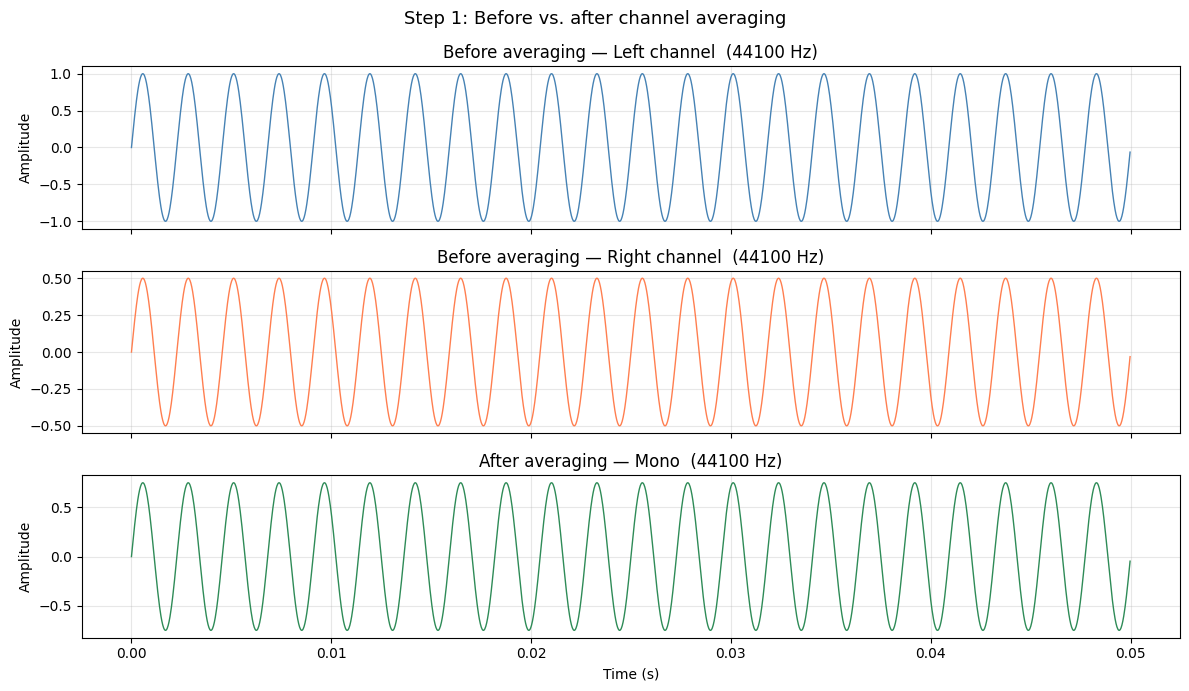

In [46]:
demo_path = ensure_demo_stereo()
stereo_np, sr = load_wav(str(demo_path))

print("=== DIAGNOSTICS ===")
print(f"Stereo input - Left channel max: {stereo_np[:, 0].max():.4f}, min: {stereo_np[:, 0].min():.4f}")
print(f"Stereo input - Right channel max: {stereo_np[:, 1].max():.4f}, min: {stereo_np[:, 1].min():.4f}")

# Stage 1: averaging (stereo -> mono, same sample rate)
wav = to_channel_first_tensor(stereo_np)
wav_mono = stereo_to_mono(wav)
mono_after_averaging = wav_mono.squeeze().cpu().numpy()

print(f"\nAfter averaging - Mono max: {mono_after_averaging.max():.4f}, min: {mono_after_averaging.min():.4f}")
print(f"Expected amplitude after averaging: 0.75 (average of 1.0 and 0.5)")
print(f"Actual peak amplitude: {max(abs(mono_after_averaging.max()), abs(mono_after_averaging.min())):.4f}")

# Visualization: before vs. after averaging
print("\n=== GENERATING PLOT ===")
plot_before_after_averaging(stereo_np, sr, mono_after_averaging, max_seconds=0.05)
plt.show()

## 12. Flow Summary

```
Stereo WAV (.wav)
    ↓  soundfile.read()
NumPy [samples, 2]
    ↓  transpose + torch tensor
Tensor [2, samples]
    ↓  torch.mean(dim=0)  ← stereo-to-mono
Tensor [1, samples]
    ↓  resample (if sr ≠ 16000)
Tensor [1, samples @ 16kHz]
    ↓  squeeze
NumPy [samples]  →  ready for downstream use
```

## Key Point

**Stereo-to-mono is done by averaging the two channels.** No separate mono file is required — conversion happens in memory. You can optionally save the result:

```python
sf.write("demo_mono.wav", mono_output, output_sr)
```

In [47]:
demo_path = ensure_demo_stereo()
mono_output, output_sr = preprocess_stereo_to_mono(str(demo_path))

demo_mono_path = demo_path.parent / "demo_mono.wav"
sf.write(demo_mono_path, mono_output, output_sr)
print(f"Saved mono output to: {demo_mono_path}")

Saved mono output to: demo_audio\demo_mono.wav


## Conclusion

### What You Learned

In this tutorial, you learned how to convert stereo audio to mono and resample it to 16 kHz — a fundamental preprocessing step for many speech recognition systems.

**Key concepts covered:**

1. **Audio File Formats**
   - WAV files store uncompressed PCM audio with metadata (sample rate, channels, bit depth)
   - Mono vs. stereo: 1 channel vs. 2 channels (left/right)
   - Sample rate determines how many measurements per second (e.g., 44100 Hz vs. 16000 Hz)

2. **Acoustic Terminology**
   - **Sample**: one measurement of amplitude at a point in time
   - **Waveform**: the complete sequence of samples over time
   - **Channel**: an independent audio stream
   - **Downmixing**: combining multiple channels into fewer channels
   - **Resampling**: changing the sample rate without changing frequency content

3. **The Conversion Pipeline**
   - Load WAV → NumPy array (using `soundfile`)
   - Convert to PyTorch tensor for processing (shape: `[channels, samples]`)
   - Average channels: `torch.mean(dim=0)` → mono
   - Resample: `torchaudio.transforms.Resample` → 16 kHz
   - Return 1D NumPy array ready for downstream use

4. **Why This Matters**
   - Many ASR models (including the IBM Granite Speech model used in medical transcription) require mono audio at a specific sample rate
   - Stereo recordings are common but contain redundant speech information
   - Channel averaging preserves speech content while reducing to a single channel
   - 16 kHz sample rate is standard for speech recognition (captures frequencies up to 8 kHz via Nyquist theorem)

5. **Visualization Insights**
   - The averaged mono waveform sits between the left and right channels
   - With left channel amplitude 1.0 and right 0.5, the mono result is 0.75 (their average)
   - The visualization confirms the mathematical operation matches the actual signal processing

### Next Steps

You can now:
- Apply this pipeline to your own stereo audio files
- Integrate it into ASR workflows (speech-to-text systems)
- Adapt the code for different target sample rates or channel configurations
- Build upon this foundation for more complex audio preprocessing tasks

### Files Generated

This tutorial created:
- `demo_audio/demo_stereo.wav` — synthetic stereo test file (440 Hz tone, 1 second)
- `demo_audio/demo_mono.wav` — mono output after conversion (16 kHz)

All preprocessing happens **in memory** — no intermediate files are required unless you explicitly save them.